## ECMWF

In [19]:
#請確保已安裝Herbie(pip install Herbie-data)
from herbie import Herbie

import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as feature
import matplotlib.pyplot as plt
import numpy as np

from herbie import paint
from herbie.toolbox import EasyMap, pc
from scipy.interpolate import griddata
import scipy.ndimage

In [9]:
H = Herbie("2026-3-16-00", model="ifs", product="oper", fxx=120)

H.grib, H.idx

✅ Found ┊ model=ifs ┊ product=oper ┊ 2026-Mar-16 00:00 UTC F120 ┊ GRIB2 @ aws ┊ IDX @ aws


('https://ecmwf-forecasts.s3.eu-central-1.amazonaws.com/20260316/00z/ifs/0p25/oper/20260316000000-120h-oper-fc.grib2',
 'https://ecmwf-forecasts.s3.eu-central-1.amazonaws.com/20260316/00z/ifs/0p25/oper/20260316000000-120h-oper-fc.index')

In [10]:
ds_2=H.xarray("100u")
ds_2=ds_2.sel(latitude=slice(25, 21), longitude=slice(112, 116))
ds_3=H.xarray("100v")
ds_3=ds_3.sel(latitude=slice(25, 21), longitude=slice(112, 116))
ds_4=H.xarray("100[u|v]").herbie.with_wind()
ds_4=ds_4.sel(latitude=slice(25, 21), longitude=slice(112, 116))
ds_6=H.xarray(":msl:")
ds_6=ds_6.sel(latitude=slice(25, 21), longitude=slice(112, 116))

/opt/anaconda3/lib/python3.11/site-packages/cfgrib/xarray_plugin.py:131: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  vars, attrs, coord_names = xr.conventions.decode_cf_variables(
/opt/anaconda3/lib/python3.11/site-packages/cfgrib/xarray_plugin.py:131: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  vars, attrs, coord_names = xr.conventions.decode_cf_variables(
/opt/anaconda3/lib/python3.11/site-packages/cfgrib/xarray_plugin.py:131: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  vars, attrs, coord_names = xr.conventions.decode_cf_var

/opt/anaconda3/lib/python3.11/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


Text(1.0, 1.0, 'MSLP and 100 m wind(smoothed)')

/opt/anaconda3/lib/python3.11/site-packages/shapely/predicates.py:778: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)
/opt/anaconda3/lib/python3.11/site-packages/shapely/predicates.py:778: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)
/opt/anaconda3/lib/python3.11/site-packages/shapely/predicates.py:778: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)
/opt/anaconda3/lib/python3.11/site-packages/shapely/predicates.py:778: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)
/opt/anaconda3/lib/python3.11/site-packages/shapely/predicates.py:778: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)
/opt/anaconda3/lib/python3.11/site-packages/shapely/predicates.py:778: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs

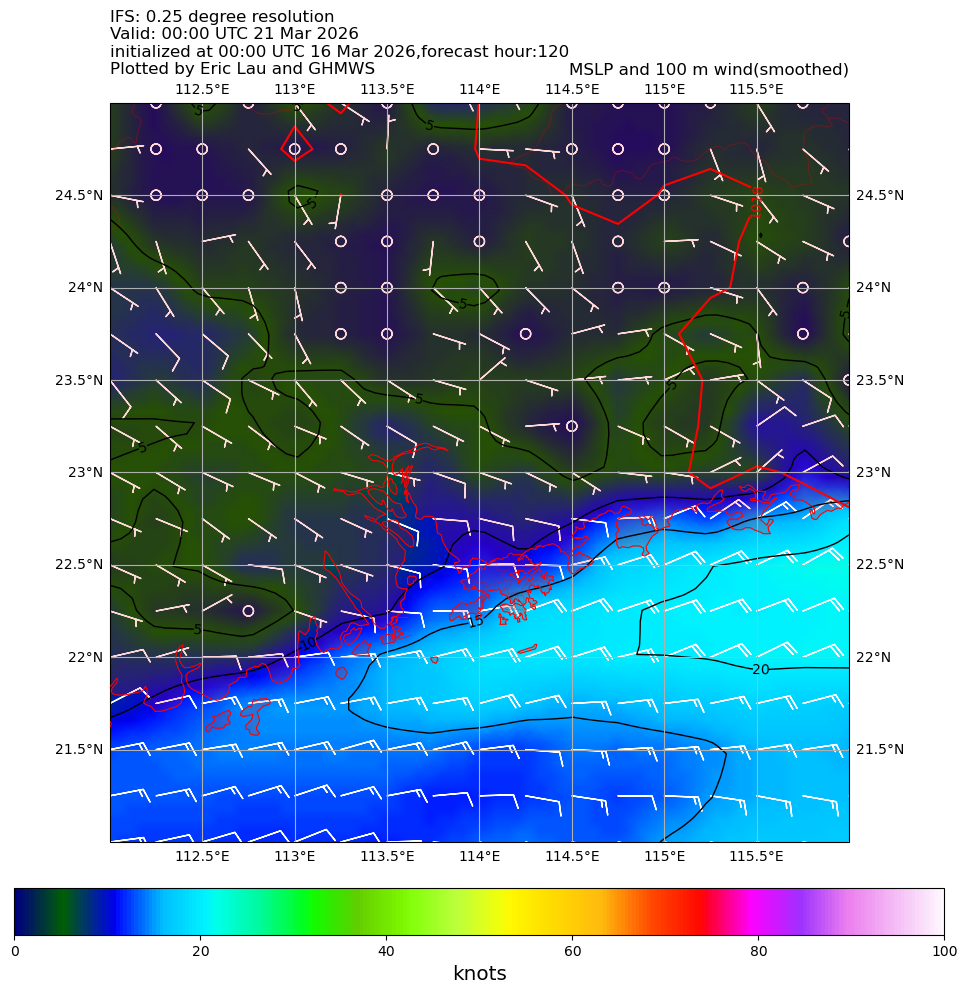

In [11]:
ax = EasyMap("10m", crs=ds_2.herbie.crs, figsize=[12, 12],color='red').STATES().BORDERS().ax
ds_5=scipy.ndimage.zoom(ds_4.si100,4,order=1)
longitude=scipy.ndimage.zoom(ds_4.longitude,4,order=1)
latitude=scipy.ndimage.zoom(ds_4.latitude,4,order=1)
p = ax.pcolormesh(
    longitude,
    latitude,
    ds_5*3.6/1.852,
    transform=pc,
    cmap="gist_ncar",
    vmin=0,
    vmax=100,
    shading='gouraud'
#    **paint.NWSTemperature.kwargs2,
)
y=plt.colorbar(
     p, ax=ax, orientation="horizontal", pad=0.05,cmap='nipy_spectral')
#y=plt.colorbar(
#    p, ax=ax, orientation="horizontal", pad=0.05, cmap="gist_ncar")
y.set_label('knots',size='x-large')
ax.barbs(ds_2.longitude,ds_3.latitude,ds_2.u100*3.6/1.852,ds_3.v100*3.6/1.852,barbcolor='w')
#ds_5=scipy.ndimage.zoom(ds.si100*3.6/1.852,7,order=1)
#longitude=scipy.ndimage.zoom(ds.longitude,7,order=1)
#latitude=scipy.ndimage.zoom(ds.latitude,7,order=1)
x=plt.contour(longitude, latitude, ds_5*3.6/1.852,levels=np.arange(0,100,5),colors='k',linewidths=1, transform=pc)
plt.clabel(x, fontsize=10, inline=1, inline_spacing=1, fmt='%i', rightside_up=True)
z=plt.contour(ds_6.longitude, ds_6.latitude, ds_6.msl/100,levels=np.arange(880,1060,2),colors='red',transform=pc)
plt.clabel(z, fontsize=10, inline=1, inline_spacing=1, fmt='%i', rightside_up=True)
#plt.clabel(x, fontsize=10, inline=1, inline_spacing=1, fmt='%i', rightside_up=True)
ax.set_title(
    f"{ds_4.model.upper()}: 0.25 degree resolution\nValid: {ds_4.valid_time.dt.strftime('%H:%M UTC %d %b %Y').item()}\ninitialized at {ds_4.time.dt.strftime('%H:%M UTC %d %b %Y').item()},forecast hour:{H.fxx}\nPlotted by Eric Lau and GHMWS",
    loc="left",color='k'
)
gl=ax.gridlines(draw_labels=True)
gl.xlabels_top = False
gl.ylabels_left = False
#ax.set_extent([113,115,21.5,23.5])
ax.set_title(f"MSLP and 100 m wind(smoothed)", loc="right")

## GFS

In [5]:
H = Herbie("2026-3-16-00", model="gfs",product='pgrb2.0p25',fxx=120)

✅ Found ┊ model=gfs ┊ product=pgrb2.0p25 ┊ 2026-Mar-16 00:00 UTC F120 ┊ GRIB2 @ aws ┊ IDX @ aws


In [6]:
ds_4 = H.xarray(":UGRD:10 m above ground:")
ds_5 = H.xarray(":VGRD:10 m above ground:")
ds_6 = H.xarray(":UGRD:10 m above ground|VGRD:10 m above ground:").herbie.with_wind()
ds_2=H.xarray(":PRMSL:")
ds_2=ds_2.sel(latitude=slice(25, 21), longitude=slice(112, 116))
ds_4=ds_4.sel(latitude=slice(25,21), longitude=slice(112, 116))
ds_5=ds_5.sel(latitude=slice(25,21), longitude=slice(112, 116))
ds_6=ds_6.sel(latitude=slice(25,21), longitude=slice(112, 116))

👨🏻‍🏭 Created directory: [/Users/eknlau/data/gfs/20260316]


/opt/anaconda3/lib/python3.11/site-packages/cfgrib/xarray_plugin.py:131: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  vars, attrs, coord_names = xr.conventions.decode_cf_variables(
/opt/anaconda3/lib/python3.11/site-packages/cfgrib/xarray_plugin.py:131: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  vars, attrs, coord_names = xr.conventions.decode_cf_variables(
/opt/anaconda3/lib/python3.11/site-packages/cfgrib/xarray_plugin.py:131: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  vars, attrs, coord_names = xr.conventions.decode_cf_var

/opt/anaconda3/lib/python3.11/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


Text(1.0, 1.0, 'MSLP and 10m wind(smoothed)')

/opt/anaconda3/lib/python3.11/site-packages/shapely/predicates.py:778: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)
/opt/anaconda3/lib/python3.11/site-packages/shapely/predicates.py:778: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)
/opt/anaconda3/lib/python3.11/site-packages/shapely/predicates.py:778: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)
/opt/anaconda3/lib/python3.11/site-packages/shapely/predicates.py:778: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)
/opt/anaconda3/lib/python3.11/site-packages/shapely/predicates.py:778: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)
/opt/anaconda3/lib/python3.11/site-packages/shapely/predicates.py:778: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs

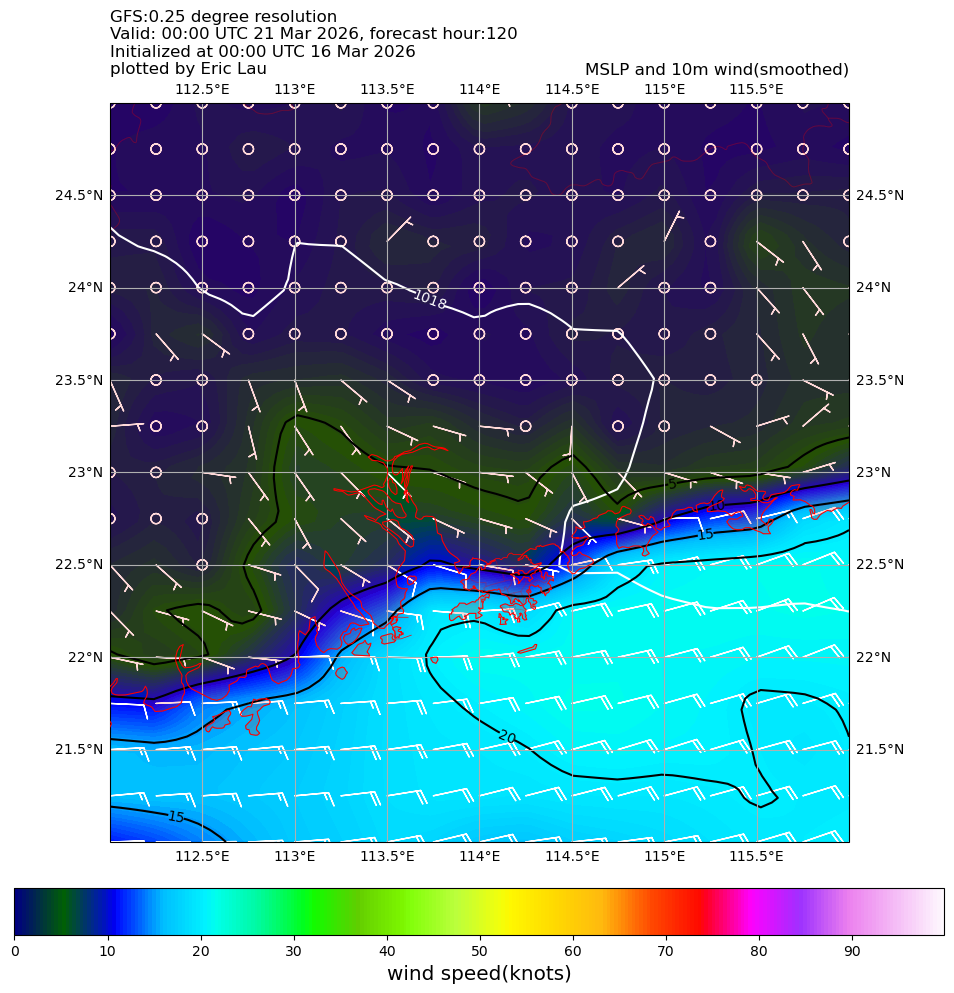

In [8]:
ax = EasyMap("10m", crs=ds_2.herbie.crs, figsize=[12, 12],color='red').STATES().BORDERS().ax
ds_3=scipy.ndimage.zoom(ds_6.si10,4,order=1)
ds_8=scipy.ndimage.zoom(ds_2.prmsl,4,order=1)
longitude=scipy.ndimage.zoom(ds_6.longitude,4,order=1)
latitude=scipy.ndimage.zoom(ds_6.latitude,4,order=1)
p = ax.contourf(
    longitude,
    latitude,
    ds_3*3.6/1.852,
    transform=pc,
    cmap='gist_ncar',
#    levels=np.arange(0,100)
    levels=np.arange(0,100,0.1)
#    **paint.NWSTemperature.kwargs2,
)
z=plt.colorbar(
    p, ax=ax, orientation="horizontal", pad=0.05
)
z.set_label('wind speed(knots)',size='x-large',color='k')
y=plt.contour(longitude,latitude,ds_8/100,levels=np.arange(880,1060,2),colors='white',transform=pc)
ax.barbs(ds_4.longitude,ds_5.latitude,ds_4.u10*3.6/1.852,ds_5.v10*3.6/1.852,barbcolor='w',rounding=True)
x=plt.contour(longitude,latitude,ds_3*3.6/1.852,levels=np.arange(0,100,5),colors='k',transform=pc)
plt.clabel(y, fontsize=10, inline=1, inline_spacing=1, fmt='%i', rightside_up=True)
plt.clabel(x, fontsize=10, inline=1, inline_spacing=1, fmt='%i', rightside_up=True)
#ax.text(longitude[74],latitude[118],f'{q}\nL',color='red',ha='center',size=16,fontweight='bold')
ax.set_title(
    f"{ds_2.model.upper()}:0.25 degree resolution\nValid: {ds_2.valid_time.dt.strftime('%H:%M UTC %d %b %Y').item()}, forecast hour:{H.fxx}\nInitialized at {ds_2.time.dt.strftime('%H:%M UTC %d %b %Y').item()}\nplotted by Eric Lau",
    loc="left",
color='black')
gl=ax.gridlines(draw_labels=True)
gl.xlabels_top = False
gl.ylabels_left = False
#ax.set_extent([110,120,18,26])
ax.set_title("MSLP and 10m wind(smoothed)", loc="right",color='black')

## AIFS

In [12]:
H = Herbie("2026-3-16-00", model="aifs", product="oper", fxx=120)

H.grib, H.idx

✅ Found ┊ model=aifs ┊ product=oper ┊ 2026-Mar-16 00:00 UTC F120 ┊ GRIB2 @ aws ┊ IDX @ aws


('https://ecmwf-forecasts.s3.eu-central-1.amazonaws.com/20260316/00z/aifs-single/0p25/oper/20260316000000-120h-oper-fc.grib2',
 'https://ecmwf-forecasts.s3.eu-central-1.amazonaws.com/20260316/00z/aifs-single/0p25/oper/20260316000000-120h-oper-fc.index')

In [13]:
ds_2=H.xarray("100u")
ds_2=ds_2.sel(latitude=slice(25, 21), longitude=slice(112, 116))
ds_3=H.xarray("100v")
ds_3=ds_3.sel(latitude=slice(25, 21), longitude=slice(112, 116))
ds_4=H.xarray("100[u|v]").herbie.with_wind()
ds_4=ds_4.sel(latitude=slice(25, 21), longitude=slice(112, 116))
ds_6=H.xarray(":msl:")
ds_6=ds_6.sel(latitude=slice(25, 21), longitude=slice(112, 116))

👨🏻‍🏭 Created directory: [/Users/eknlau/data/aifs/20260316]


/opt/anaconda3/lib/python3.11/site-packages/cfgrib/xarray_plugin.py:131: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  vars, attrs, coord_names = xr.conventions.decode_cf_variables(
/opt/anaconda3/lib/python3.11/site-packages/cfgrib/xarray_plugin.py:131: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  vars, attrs, coord_names = xr.conventions.decode_cf_variables(
/opt/anaconda3/lib/python3.11/site-packages/cfgrib/xarray_plugin.py:131: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  vars, attrs, coord_names = xr.conventions.decode_cf_var

/opt/anaconda3/lib/python3.11/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


Text(1.0, 1.0, 'MSLP and 100 m wind(smoothed)')

/opt/anaconda3/lib/python3.11/site-packages/shapely/predicates.py:778: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)
/opt/anaconda3/lib/python3.11/site-packages/shapely/predicates.py:778: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)
/opt/anaconda3/lib/python3.11/site-packages/shapely/predicates.py:778: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)
/opt/anaconda3/lib/python3.11/site-packages/shapely/predicates.py:778: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)
/opt/anaconda3/lib/python3.11/site-packages/shapely/predicates.py:778: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs)
/opt/anaconda3/lib/python3.11/site-packages/shapely/predicates.py:778: RuntimeWarning: invalid value encountered in intersects
  return lib.intersects(a, b, **kwargs

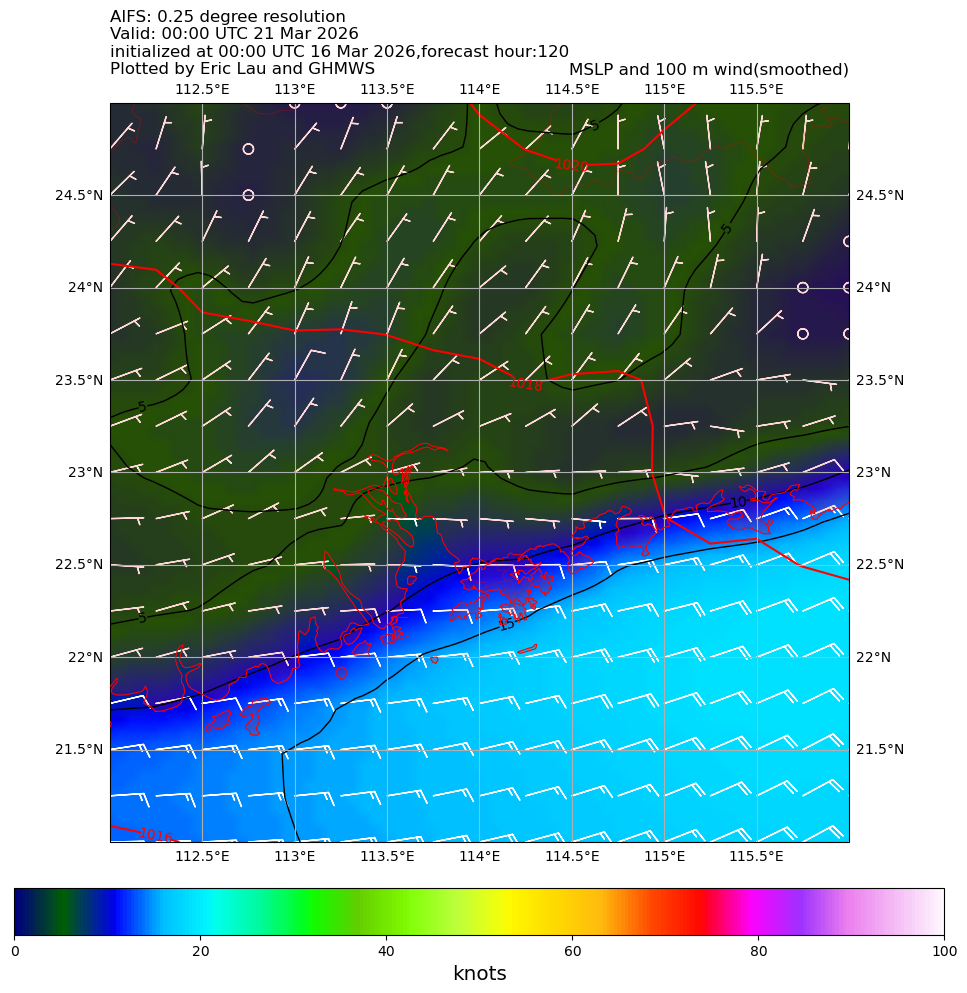

In [14]:
ax = EasyMap("10m", crs=ds_2.herbie.crs, figsize=[12, 12],color='red').STATES().BORDERS().ax
ds_5=scipy.ndimage.zoom(ds_4.si100,4,order=1)
longitude=scipy.ndimage.zoom(ds_4.longitude,4,order=1)
latitude=scipy.ndimage.zoom(ds_4.latitude,4,order=1)
p = ax.pcolormesh(
    longitude,
    latitude,
    ds_5*3.6/1.852,
    transform=pc,
    cmap="gist_ncar",
    vmin=0,
    vmax=100,
    shading='gouraud'
#    **paint.NWSTemperature.kwargs2,
)
y=plt.colorbar(
     p, ax=ax, orientation="horizontal", pad=0.05,cmap='nipy_spectral')
#y=plt.colorbar(
#    p, ax=ax, orientation="horizontal", pad=0.05, cmap="gist_ncar")
y.set_label('knots',size='x-large')
ax.barbs(ds_2.longitude,ds_3.latitude,ds_2.u100*3.6/1.852,ds_3.v100*3.6/1.852,barbcolor='w')
#ds_5=scipy.ndimage.zoom(ds.si100*3.6/1.852,7,order=1)
#longitude=scipy.ndimage.zoom(ds.longitude,7,order=1)
#latitude=scipy.ndimage.zoom(ds.latitude,7,order=1)
x=plt.contour(longitude, latitude, ds_5*3.6/1.852,levels=np.arange(0,100,5),colors='k',linewidths=1, transform=pc)
plt.clabel(x, fontsize=10, inline=1, inline_spacing=1, fmt='%i', rightside_up=True)
z=plt.contour(ds_6.longitude, ds_6.latitude, ds_6.msl/100,levels=np.arange(880,1060,2),colors='red',transform=pc)
plt.clabel(z, fontsize=10, inline=1, inline_spacing=1, fmt='%i', rightside_up=True)
#plt.clabel(x, fontsize=10, inline=1, inline_spacing=1, fmt='%i', rightside_up=True)
ax.set_title(
    f"{ds_4.model.upper()}: 0.25 degree resolution\nValid: {ds_4.valid_time.dt.strftime('%H:%M UTC %d %b %Y').item()}\ninitialized at {ds_4.time.dt.strftime('%H:%M UTC %d %b %Y').item()},forecast hour:{H.fxx}\nPlotted by Eric Lau and GHMWS",
    loc="left",color='k'
)
gl=ax.gridlines(draw_labels=True)
gl.xlabels_top = False
gl.ylabels_left = False
#ax.set_extent([113,115,21.5,23.5])
ax.set_title(f"MSLP and 100 m wind(smoothed)", loc="right")